# Labeling

In [ ]:
pd.read_csv('Hasil_Preprocessing.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15984 entries, 0 to 19999
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Rating         15984 non-null  int64 
 1   Review         15984 non-null  object
 2   cleaning       15984 non-null  object
 3   case folding   15984 non-null  object
 4   normalization  15984 non-null  object
 5   tokenize       15984 non-null  object
 6   text stopword  15984 non-null  object
 7   stem_text      15984 non-null  object
dtypes: int64(1), object(7)
memory usage: 1.1+ MB


In [ ]:
df = pd.DataFrame(df[['stem_text']])
df.head()

,stem_text
0,baik
1,alhamdulillah puas aplikasi
2,ok
3,bagus
4,shopee mantap bonus


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15984 entries, 0 to 19999
Data columns (total 1 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   stem_text  15984 non-null  object
dtypes: object(1)
memory usage: 249.8+ KB


In [ ]:
import pandas as pd
import requests

pos_url = 'https://raw.githubusercontent.com/fajri91/InSet/master/positive.tsv'
neg_url = 'https://raw.githubusercontent.com/fajri91/InSet/master/negative.tsv'

pos_lexicon = set(pd.read_csv(pos_url, sep='\t', header=None)[0])
neg_lexicon = set(pd.read_csv(neg_url, sep='\t', header=None)[0])

# Hitung sentimen dan skor
def sentiment(text):
  if not isinstance(text, str):
    return 0, 'Netral'

  words = text.lower().split()

  positif = 0
  negatif = 0

  for w in words:
    if w in pos_lexicon:
      positif += 1
    if w in neg_lexicon:
      negatif += 1

  score = positif - negatif

  if score > 0:
    label = 'Positif'
  elif score < 0:
    label = 'Negatif'
  else:
    label = 'Netral'
  return score, label

# tentukan sentimen dan skor
df[['Score','Sentiment']] = df['stem_text'].apply(lambda x: pd.Series(sentiment(x)))

df.head(5)

,stem_text,Score,Sentiment
0,baik,0,Netral
1,alhamdulillah puas aplikasi,1,Positif
2,ok,1,Positif
3,bagus,0,Netral
4,shopee mantap bonus,1,Positif


In [ ]:
df.to_csv('Labeling.csv', encoding='utf8')
df.head()

,stem_text,Score,Sentiment
0,baik,0,Netral
1,alhamdulillah puas aplikasi,1,Positif
2,ok,1,Positif
3,bagus,0,Netral
4,shopee mantap bonus,1,Positif


In [ ]:
df.isnull().sum()

,0
stem_text,0
Score,0
Sentiment,0


In [ ]:
sentiment_counts = df['Sentiment'].value_counts()
sentiment_counts

,count
Sentiment,
Positif,7488
Netral,5129
Negatif,3367


# Training

# BiLSTM

Algoritma : BiLSTM

Ekstrasi Fitur : Keras Embedding Layer

Pembagian data : 80 % Training / 20 % Testing


In [ ]:
!pip install tensorflow

import numpy as np
import pandas as pd

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer # mengubah teks jadi angka
from tensorflow.keras.utils import pad_sequences #panjang input
from tensorflow.keras.models import Sequential # mengubah ID kata
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [ ]:
text = df["stem_text"].fillna('').astype(str).values
label = df['Sentiment'].astype(str).str.strip().str.lower().values

# encoding label untuk mengubah string ke angka
label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(label)
num_classes = len(label_encoder.classes_)

# split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    text, encoded_labels, test_size=0.2, random_state=42, stratify=encoded_labels
)

print(f"Training data size: {len(X_train)}")
print(f"Testing data size: {len(X_test)}")

vocab_size = 10000
max_length = 150

# tokenizer

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train) # membangun kamus dari data train

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# padding
X_train_padded = pad_sequences(X_train_seq, maxlen=max_length, padding="post", truncating="post")
X_test_padded = pad_sequences(X_test_seq, maxlen=max_length, padding="post", truncating="post")

# class weight berfungsi untuk data balance
classweight = compute_class_weight('balanced', classes=np.unique(encoded_labels), y=encoded_labels)
class_weight = dict(zip(np.unique(encoded_labels), classweight))


# modelling
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=128, input_length=max_length), #mengubah hasil tokenizer jadi vektor
    Bidirectional(LSTM(64, return_sequences=True)),
    Bidirectional(LSTM(32)),
    Dropout(0.3),
    Dense(64, activation="relu"), # layer belajar dari fitur
    Dense(num_classes, activation="softmax") #output probabilitas per kelas
])

model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

Training data size: 12787
Testing data size: 3197


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
print("Classes:", label_encoder.classes_) # cek apakah benar 3 kelas

Classes: ['negatif' 'netral' 'positif']


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

callback_stop = EarlyStopping(
    monitor='val_loss',
    patience=3, #jika tidak baik cukup 3 aja
    restore_best_weights=True
    )

In [ ]:
model.fit(
    X_train_padded, y_train, #data training fitur & label
    epochs=20, #maksimal 20 putaran tergantung callback, jika sudah cukup akan berhenti
    batch_size=16,
    validation_data=(X_test_padded, y_test),
    callbacks=[callback_stop],
    class_weight=class_weight
)

y_pred = model.predict(X_test_padded)
y_pred_classes = np.argmax(y_pred, axis=1)

Epoch 1/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 244s 292ms/step - accuracy: 0.6221 - loss: 0.7621 - val_accuracy: 0.8977 - val_loss: 0.2651
Epoch 2/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 241s 301ms/step - accuracy: 0.9347 - loss: 0.1951 - val_accuracy: 0.9159 - val_loss: 0.2217
Epoch 3/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 231s 288ms/step - accuracy: 0.9657 - loss: 0.1036 - val_accuracy: 0.9340 - val_loss: 0.1924
Epoch 4/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 260s 286ms/step - accuracy: 0.9830 - loss: 0.0534 - val_accuracy: 0.9215 - val_loss: 0.2800
Epoch 5/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 272s 298ms/step - accuracy: 0.9882 - loss: 0.0383 - val_accuracy: 0.9296 - val_loss: 0.2593
Epoch 6/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 238s 298ms/step - accuracy: 0.9880 - loss: 0.0407 - val_accuracy: 0.9296 - val_loss: 0.3484
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 92ms/step


In [ ]:
print("="*4,'Akurasi terakhir','='*4)

# akurasi training
loss_train, accuracy_train = model.evaluate( X_train_padded, y_train, verbose=0)
print(f"Akurasi Training: {accuracy_train * 100:.2f}%")

#  akurasi test
loss_test, accuracy_test = model.evaluate(X_test_padded, y_test, verbose=0)
print(f"Akurasi Testing: {accuracy_test * 100:.2f}%")

# # Classification Report
# print(Classification_report(y_test, y_pred_classess, target_names=label_encoder.classes_))

==== Akurasi terakhir ====
Akurasi Training: 98.34%
Akurasi Testing: 93.40%


# Output algoritma BilSTM / Bukti Akurasi Terakhir
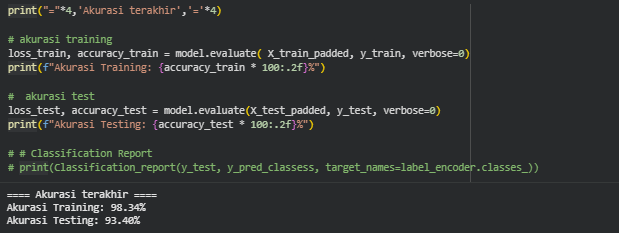

Kesimpulan akurasi terakhir: model memperoleh akurasi training sebesar 98.3 dan akurasi testing sebesar 93.48 , hasil menunjukan model memiliki kemampuan yang baik dan tidak mengalami overfitting.

## Cek prediksi

In [ ]:
# Ubah prediksi angka menjadi label string
y_pred_labels = label_encoder.inverse_transform(y_pred_classes)
y_true_labels = label_encoder.inverse_transform(y_test)

# Tampilkan hasil
hasil_testing = pd.DataFrame({
    "text": X_test[:10],
    "label_asli": y_true_labels[:10],
    "label_prediksi": y_pred_labels[:10],
})
hasil_testing

,text,label_asli,label_prediksi
0,shopee mantullll,netral,netral
1,masuk langsung masuk video ngabisin kuota kuot...,negatif,negatif
2,oke membanti,positif,positif
3,senang mengunakan aplikasi inithe best pokok,negatif,negatif
4,pesan stuck,netral,netral
5,order fiktif,netral,netral
6,muas kembali dana jam,positif,positif
7,bijak lin,netral,netral
8,masalah kurir sat set lelet tolong baik kontak...,netral,negatif
9,mantap harga murah original lengkap,positif,positif


In [ ]:
# percobaan prediksi
def predict(input_text:str):
  input_text = ' ' if input_text is None else str(input_text)

  seq = tokenizer.texts_to_sequences([input_text])
  pad = pad_sequences(seq, maxlen=max_length, padding="post", truncating="post")

  prob = model.predict(pad, verbose=0)[0] # untuk array probilitas per kelas
  pred_idx = int(np.argmax(prob)) # kelas angka
  pred_label = label_encoder.inverse_transform([pred_idx])[0]

  return pred_label, prob

contoh_kalimat = []
while True:
    kalimat = input("Masukan kalimat: (ketik Exit untuk keluar) ").strip()
    if not kalimat:
        break

    if kalimat.lower() == "exit":
      print('keluar, terimakasih')
      break

    if kalimat == "":
        print("Input kosong (tidak diproses).")
        continue

    #  kalimat ini yang akan digunakan:
    # 'bagus banget aplikasinya',
    # 'paket yang datang tidak bagus dan tidak sesuai

    label_prediksi, probabilitas = predict(kalimat)
    print("Teks:", kalimat)
    print("Prediksi:", label_prediksi)
    print("-" *10)

Masukan kalimat: (ketik Exit untuk keluar) bagus banget aplikasinya
Teks: bagus banget aplikasinya
Prediksi: positif
----------
Masukan kalimat: (ketik Exit untuk keluar) paket yang datang tidak bagus dan tidak sesuai
Teks: paket yang datang tidak bagus dan tidak sesuai
Prediksi: negatif
----------
Masukan kalimat: (ketik Exit untuk keluar) exit
kamu keluar, terimakasih


In [ ]:
print(df["Sentiment"].value_counts())

Sentiment
Positif    7488
Netral     5129
Negatif    3367
Name: count, dtype: int64


# SVM
Algoritma: SVM

Ekstraksi Fitur: TF-IDF

Pembagian Data: 80% Training / 20% Testing

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer # ubah teks jadi angka pakai TF-IDF
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score # akurasi skor

In [ ]:
x = df["stem_text"].fillna("").astype(str).values
y = df["Sentiment"].astype(str).str.strip().str.lower().values

# split 80/20
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2,random_state=42,stratify=y)

# TF-IDF
tfidf = TfidfVectorizer(
    ngram_range=(1,1),
    max_features=10000,
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# SVM
svm = LinearSVC(C=2,class_weight='balanced',random_state=42)
svm.fit(X_train_tfidf, y_train)

# predict
y_pred_train = svm.predict(X_train_tfidf)
y_pred_test = svm.predict(X_test_tfidf)

# Akurasi
print(4*'=','Akurasi Akhir',4*'=')
print(f'Akurasi Training: {(accuracy_score(y_train, y_pred_train)* 100):.2f}%')
print(f'Akurasi Testing : {(accuracy_score(y_test, y_pred_test)* 100):.2f}%')


==== Akurasi Akhir ====
Akurasi Training: 96.90%
Akurasi Testing : 88.93%


## Output SVM / Bukti Akurasi Akhir
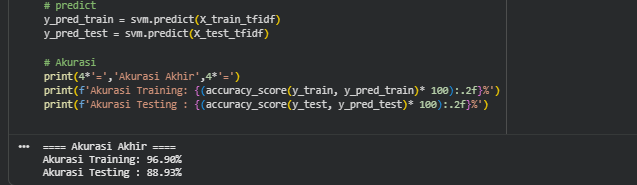

Model menghasilkan akurasi training sebesar 98.9% sedangkan akurasi testing sebesar 88,9%. Secara keseluruhan, model SVM mampu memberikan hasil klasifikasi yang baik namun performanya sedikit lebih rendah dibandingkan dengan BilSTM dan Dense Neural Network

## Cek Prediksi

In [ ]:
hasil = pd.DataFrame({
    "text": X_test[:10],
    "label_asli": y_test[:10],
    "label_prediksi": y_pred_test[:10],
})

hasil

,text,label_asli,label_prediksi
0,shopee mantullll,netral,netral
1,masuk langsung masuk video ngabisin kuota kuot...,negatif,negatif
2,oke membanti,positif,positif
3,senang mengunakan aplikasi inithe best pokok,negatif,netral
4,pesan stuck,netral,netral
5,order fiktif,netral,netral
6,muas kembali dana jam,positif,positif
7,bijak lin,netral,netral
8,masalah kurir sat set lelet tolong baik kontak...,netral,netral
9,mantap harga murah original lengkap,positif,positif


In [ ]:
print(df["Sentiment"].value_counts())

Sentiment
Positif    7488
Netral     5129
Negatif    3367
Name: count, dtype: int64


#Dense Neural Network

Algoritma : Dense Neural Network

Ekstrasi Fitur: TF-IDF

Pembagian Data : 70% Training/ 30% Testing

In [ ]:
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input,Dense, Dropout

In [ ]:
text = df["stem_text"].fillna('').astype(str).values
label = df["Sentiment"].astype(str).str.strip().str.lower().values

# Encodeing label

label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(label)
num_classes = len(label_encoder.classes_)
y_one_hot = to_categorical(encoded_labels, num_classes=num_classes)

# split 70/30
X_train, X_test, y_train, y_test = train_test_split(
    text, y_one_hot, test_size=0.3, random_state=42, stratify=encoded_labels
)
print(f"Training data size: {len(X_train)}")
print(f"Testing data size: {len(X_test)}")

# TF-IDF
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,1),
    min_df=2, # buang kata muncul <2 (noise)
    max_df=0.9, #buang kata terlalu umum
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train).toarray()
X_test_tfidf = tfidf.transform(X_test).toarray()


# class weight berfungsi data balance
classweight = compute_class_weight('balanced', classes=np.unique(encoded_labels), y=encoded_labels)
class_weight = dict(zip(np.unique(encoded_labels), classweight))

# Model Dense
model = Sequential([
    Input(shape=(X_train_tfidf.shape[1],)),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

Training data size: 11188
Testing data size: 4796


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

callback_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
    )

In [ ]:
model.fit(
    X_train_tfidf, y_train,
    epochs=20,
    batch_size=16,
    validation_data=(X_test_tfidf, y_test),
    callbacks=[callback_stop],
    class_weight=class_weight
)

y_pred = model.predict(X_test_tfidf)
y_pred_classes = np.argmax(y_pred, axis=1)

Epoch 1/20
700/700 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - accuracy: 0.6525 - loss: 0.7971 - val_accuracy: 0.8964 - val_loss: 0.2746
Epoch 2/20
700/700 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.9210 - loss: 0.2289 - val_accuracy: 0.9128 - val_loss: 0.2341
Epoch 3/20
700/700 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.9659 - loss: 0.1188 - val_accuracy: 0.9210 - val_loss: 0.2300
Epoch 4/20
700/700 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.9815 - loss: 0.0677 - val_accuracy: 0.9156 - val_loss: 0.2674
Epoch 5/20
700/700 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.9869 - loss: 0.0460 - val_accuracy: 0.9164 - val_loss: 0.2862
Epoch 6/20
700/700 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.9890 - loss: 0.0348 - val_accuracy: 0.9183 - val_loss: 0.2935
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [ ]:
# Evaluasi
train_loss, train_acc = model.evaluate(X_train_tfidf, y_train, verbose=0)
test_loss, test_acc = model.evaluate(X_test_tfidf, y_test, verbose=0)

print("="*4,'Akurasi terakhir','='*4)
print(f"Akurasi Training: {train_acc*100:.2f}%")
print(f"Akurasi Testing: {test_acc*100:.2f}%")

==== Akurasi terakhir ====
Akurasi Training: 99.29%
Akurasi Testing: 92.10%


## Output Dense Neural Network / Bukti Akurasi Terakhir
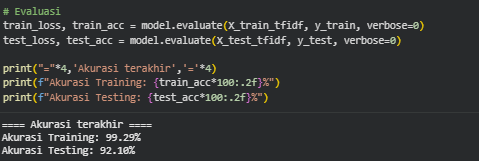

Model menunjukan performa yang sangat baik, Model memperoleh akurasi training sebesar 99.2% dan akurasi testing sebesar 92.10%.

## Cek Prediksi

In [ ]:
# prediksi probabilitas untuk dataset
y_pred_prob = model.predict(X_test_tfidf, verbose=0)

# ambil kelas angka
y_pred_classes = np.argmax(y_pred_prob, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# langkah selanjutnya ubah angka menjadi label string
y_pred_labels = label_encoder.inverse_transform(y_pred_classes)
y_true_labels = label_encoder.inverse_transform(y_true_classes)

# Tampilkan hasil 10 data
hasil_testing = pd.DataFrame({
    "text": X_test[:10],
    'label_asli': y_true_labels[:10],
    'label_prediksi': y_pred_labels[:10] # Slicing y_pred_labels here
})

hasil_testing

,text,label_asli,label_prediksi
0,aplikasi belnja bagus,negatif,negatif
1,bagus cocok orang belanja ribet terimakasih mu...,negatif,negatif
2,kasih voucher pas dicekout kena batal mulu,netral,netral
3,kecewa gue aplikasi download pesan makan maaf ...,negatif,negatif
4,kali order shopee kecewa moga,positif,positif
5,fitur siap manja pakai aplikasi,netral,netral
6,mantap sukses,positif,positif
7,bagus banget,positif,positif
8,gj benget minggu,netral,negatif
9,suka belanja shopee kirim cepat tepattapi kiri...,positif,positif


In [ ]:
print(df["Sentiment"].value_counts())

Sentiment
Positif    7488
Netral     5129
Negatif    3367
Name: count, dtype: int64


# Install Freeze

In [ ]:
!pip freeze

absl-py==1.4.0
accelerate==1.12.0
access==1.1.10.post3
affine==2.4.0
aiofiles==24.1.0
aiohappyeyeballs==2.6.1
aiohttp==3.13.3
aiosignal==1.4.0
aiosqlite==0.22.1
alabaster==1.0.0
albucore==0.0.24
albumentations==2.0.8
ale-py==0.11.2
alembic==1.18.4
altair==5.5.0
annotated-doc==0.0.4
annotated-types==0.7.0
antlr4-python3-runtime==4.9.3
anyio==4.12.1
anywidget==0.9.21
apsw==3.51.2.0
apswutils==0.1.2
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
array_record==0.8.3
arrow==1.4.0
arviz==0.22.0
astropy==7.2.0
astropy-iers-data==0.2026.2.16.0.48.25
astunparse==1.6.3
atpublic==5.1
attrs==25.4.0
audioread==3.1.0
Authlib==1.6.8
autograd==1.8.0
babel==2.18.0
backcall==0.2.0
beartype==0.22.9
beautifulsoup4==4.13.5
betterproto==2.0.0b6
bigframes==2.35.0
bigquery-magics==0.10.3
bleach==6.3.0
blinker==1.9.0
blis==1.3.3
blobfile==3.2.0
blosc2==4.0.0
bokeh==3.7.3
Bottleneck==1.4.2
bqplot==0.12.45
branca==0.8.2
brotli==1.2.0
CacheControl==0.14.4
cachetools==7.0.1
catalogue==2.0.10
certifi==2026.1.4
cf

In [ ]:
!pip freeze > requirements.txt

In [ ]:
from google.colab import files
files.download('requirements.txt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>